# Assignment 1: PyTorch Basics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Overview

In this assignment, you will:
1. Build a simple neural network from scratch to understand how neural networks work.
2. Train a neural network (using PyTorch) to classify images from the Mechanical Tools Classification dataset into one of 8 classes (hammer, wrench, pliers, etc.).

The provided code will guide you through key steps, but by the end of the assignment, you should:

1. Understand the training loop for a machine learning model.
2. Distinguish between training, validation, and test data.
3. Learn about overfitting and underfitting.
4. Explore how hyperparameters, like learning rate and batch size, impact training.
5. Compare a basic feedforward neural network (ANN) with a convolutional neural network (CNN).

This assignment is inspired by materials developed by Prof. Lisa Zhang.


## What to Submit

1. Submit the `.ipynb` and `.html` files containing your code, outputs, and answers from all parts. Please take extra effort to make your answers and submissions readable. Do not display unnecessary outputs, only the ones that are important for supporting your answers.

  You can produce a HTML file directly from Google Colab. The Colab instructions are provided at the end of this document.


2. Submit your model predictions on the secret test dataset for Parts B-5 and B-6 as `labels_part5.csv` and `labels_part6.csv`.

**Important**: Do not submit additional files generated by your code.

Please use Google Colab for this assignment. If you prefer Jupyter Notebook, ensure the file is uploaded to Colab for submission.


## Colab Link

Include a link to your colab file here and ensure the file can be accessed by the our teaching team.

Colab Link:

In [ ]:
# TO BE COMPLETED

https://colab.research.google.com/drive/14yr3NnmOkitk-ehmV5UFoK_b64cqGzaY

# PART A: Building a Neural Network from Scratch [8pt]

Before we get into using PyTorch to train our classifier we will go through the process of creating our neural network from scratch. We've seen in the tutorial how to build a 1-layer network, now we'll take it one step further to build a 2-layer network. This is an important exercise that everyone should attempt at least once to understand and truly appreciate the workings of neural networks.

## Helper Functions

To help guide the construction we will use the iris dataset that was introduced in the tutorial. Provided are some helper code to get us started:


In [ ]:
# load "Iris_3class.csv" to Google Colab
from google.colab import files
uploaded = files.upload()

Saving Iris_3class.csv to Iris_3class (1).csv


In [ ]:
import pandas as pd
import numpy as np

raw_data = pd.read_csv("Iris_3class.csv", header = None)
raw_data = raw_data.values
np.random.shuffle(raw_data)

In [ ]:
import numpy as np

# split your data into training and validation
X_train = raw_data[0:100,:4]
y_train = raw_data[0:100,4:5].astype(int)
X_val = raw_data[100:,:4]
y_val = raw_data[100:,4:5].astype(int)

print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 1)
float64 int64
(50, 4) (50, 1)
float64 int64


Recall that the neural network output consists of several nodes, one for each output class. Since the labels are provided as integers we will need to convert them into one-hot vectors to match the neural network output format.

In [ ]:
#Convert array to one-hot encoding
def to_one_hot(Y):
    n_col = np.amax(Y) + 1
    binarized = np.zeros((len(Y), n_col))
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized

In [ ]:
# a = np.array([2, 0, 1])
# print(to_one_hot(a))

In [ ]:
y_train = to_one_hot(y_train)
print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)

y_val = to_one_hot(y_val)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 3)
float64 float64
(50, 4) (50, 3)
float64 float64


In [ ]:
#verify one-hot encoding
y_train[0:5,:]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## Part A-1. Develop a 2-layer ANN [6pt MODEL]
At its core a 2-layer neural network is just a few lines of code. Most of the complexity comes from setting up the training of the network.

Using vectorized form, set up the neural network training to use a cross-entropy loss function and determine the gradients with resepect to the layer 1 and layer 2 weights.

In [ ]:
# write code to create a 2-layer ANN in vectorized form

#define sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

#define softmax
def softmax(x):
  e = np.exp(x)
  return e/e.sum(axis=1, keepdims = True)


def ann(W, X_train, y_train):

  num_hidden = 5
  num_features = 4
  num_outputs = 3

  #Weights
  w0 = W[:20].reshape(num_features, num_hidden)
  w1 = W[20:].reshape(num_hidden, num_outputs)

  #Feed forward
  layer0 = X_train
  layer1 = sigmoid(np.dot(layer0, w0))
  layer2 = np.dot(layer1, w1)

  # softmax
  y_pred = softmax(layer2)

  #Back propagation using gradient descent

#==================================== My COMPLETED CODE PART ====================================#
  #cross-entropy loss
  error = np.sum(-y_train * np.log(y_pred), axis=1)


  #initialize gradients to zero§
  dw0_value = np.zeros((num_features, num_hidden), dtype="float64")
  dw1_value = np.zeros((num_hidden, num_outputs), dtype="float64")


  #calculate gradients
  dw1 = y_pred - y_train


  #calculate gradients
  dw0 = (dw1 @ w1.T) * layer1 * (1 - layer1)



  #determine gradients
  dw1_value += layer1.T @ dw1
  dw0_value += layer0.T @ dw0


  #combine gradients into one vector
  dW = np.concatenate([dw0_value.ravel(), dw1_value.ravel()], axis=0)

#=============================================================================================#

  return (error, dW, y_pred)

## Part A-2. Train your neural network [1pt RESULT]
Train your neural network once with random initialization (uniformly at random between -1 and +1), and once with zero initialization (all weights = 0).

Compare results. Comment on how well does your network work on the iris dataset in these two cases and why?

In [ ]:
num_hidden = 5
num_features = 4
num_outputs = 3


def train_and_evaluate(w0_init, w1_init, label=""):

    #initial weights: w0_init, w1_init

    #combine weights into a single vector
    W = np.array(list(w0_init.flatten()) + list(w1_init.flatten()))

    #train network
    n = 0.001
    iterations = 100000
    errors = []
    for i in range(iterations):
        (error, dW, y_pred) = ann(W, X_train, y_train)
        W += -dW * n
        errors.append(error)

    # final predictions
    _, _, y_pred = ann(W, X_train, y_train)
    y_pred_labels = np.round(y_pred, 0)
    y_true_labels = np.round(y_train, 0)

    print(f"{label} initialization: Predictions on training data: \n{y_pred_labels[:5]}")
    print(f"{label} initialization: Ground truth training data: \n{y_true_labels[:5]}")

    accuracy = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_train, axis=1))
    print(f"{label} initialization: Final training accuracy: {accuracy:.4f}")

    return errors, accuracy

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
#random initialization
w0_rand = np.random.uniform(-1, 1, (num_features, num_hidden))
w1_rand = np.random.uniform(-1, 1, (num_hidden, num_outputs))
#=============================================================================================#
errors_rand, accuracy_rand = train_and_evaluate(w0_rand, w1_rand, "Random")

Random initialization: Predictions on training data: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Random initialization: Ground truth training data: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Random initialization: Final training accuracy: 0.9900


In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
#zero initialization
w0_zero = np.zeros((num_features, num_hidden),dtype="float64")
w1_zero = np.zeros((num_hidden, num_outputs),dtype="float64")
#=============================================================================================#
errors_zero, acc_zero = train_and_evaluate(w0_zero, w1_zero, "Zero")

Zero initialization: Predictions on training data: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Zero initialization: Ground truth training data: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Zero initialization: Final training accuracy: 0.3600


In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The random initialization is much better than zero intialization.

The reason is that the gradient for zero initialization always remain the same and can't learn, while random initialization with different gradienrs and can learn from data.

'''

## Part A-3. Validation [2pt MODEL]
Validate that the gradients were computed correctly for the 2-layer neural network you developed.

In [ ]:
#write code to numerical verify the gradients you calculated

num_hidden = 5
num_features = 4
num_outputs = 3

#==================================== My COMPLETED CODE PART ====================================#
#initialize weights uniformly at random between -1 and +1, and combine weights
w0 = np.random.uniform(-1, 1, (num_features, num_hidden))
w1 = np.random.uniform(-1, 1, (num_hidden, num_outputs))
W = np.concatenate([w0.ravel(), w1.ravel()], axis=0)
#=============================================================================================#

#compute gradients analytically
(error, dW, y_pred) = ann(W, X_train, y_train)

#compute gradients numerically
dW_num = np.zeros((len(W),1))

for ind in range(len(W)):
  #reset gradients
  We1 = np.array(list(w0.flatten()) + list(w1.flatten()))
  We2 = np.array(list(w0.flatten()) + list(w1.flatten()))

#==================================== My COMPLETED CODE PART ====================================#
  #increment slightly
  We1[ind] = We1[ind] + 1e-4
  We2[ind] = We2[ind] - 1e-4
#=============================================================================================#
  #compute errors
  (error_e1, dW_e1, y_pred1) = ann(We1, X_train, y_train)
  (error_e2, dW_e2, y_pred2) = ann(We2, X_train, y_train)

#==================================== COMPLETED CODE PART ====================================#
  #obtain numerical gradients
  grad_num = (error_e1.mean() - error_e2.mean()) / (2 * 1e-4)
#=============================================================================================#

  #display difference between numerical and analytic gradients
  print(round(abs(grad_num - dW[ind]), 4), grad_num, dW[ind])


23.4291 -0.23665772935665963 -23.665773664900552
2.1156 -0.021369736905585413 -2.136973650873929
17.9863 0.1816796348974581 18.16796325123428
5.8252 0.05883994168232043 5.883993931114875
10.9085 -0.11018728583001014 -11.018729238441232
10.401 -0.1050610989772327 -10.506109987992708
2.335 -0.023585463940767326 -2.358546381308673
10.8801 0.10989970774755164 10.98997071656635
2.8473 0.0287602608972648 2.8760260603714465
10.0689 -0.10170599243353173 -10.170599390330354
17.8918 -0.18072544269776003 -18.072544508783878
1.4648 0.014795986316151755 1.479598636533888
7.7516 0.07829946253701259 7.8299462624148175
3.8008 0.038391522851899396 3.8391522229603066
2.4422 0.02466822900504262 2.46682274882106
5.7305 -0.05788410634921526 -5.788410642604989
0.8495 0.008580611885466993 0.8580611891084646
1.7899 0.018079740572440883 1.807974060093907
1.086 0.010969951445005677 1.0969951440600503
1.857 0.01875733251388567 1.8757332448911432
21.3723 -0.21588141432493657 -21.588141437322797
6.8608 -0.06930105

# PART B: Training with PyTorch

In the second part of the assignment we will see how we can use PyTorch to train a neural network to identify different Mechanical Tools.


In [ ]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Part B-0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [ ]:
###############################################################################
# Data Loading

def get_data_loader(data_dir, batch_size, seed, valid_split=0.2):
    """
    Load the Mechanical Tools Dataset, split into training, validation, and testing.

    Args:
        data_dir: The root directory of the dataset, with subdirectories for each class.
        batch_size: Number of samples per batch.
        valid_split: Fraction of the training data to be used for validation.

    Returns:
        train_loader: Iterable DataLoader for training data.
        val_loader: Iterable DataLoader for validation data.
        test_loader: Iterable DataLoader for testing data.
        classes: List of class names.
    """
    # Define transformations
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Resize to 128x128
        transforms.ToTensor(),         # Convert to Tensor
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Load the full dataset
    dataset = datasets.ImageFolder(data_dir, transform=transform)
    classes = dataset.classes  # Get class names

    # Split the dataset
    total_size = len(dataset)
    test_size = int(0.1 * total_size)  # 10% for testing
    valid_size = int(valid_split * (total_size - test_size))  # Valid from remaining
    train_size = total_size - test_size - valid_size

    g_split = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size], generator=g_split)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training

def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Normalize labels for multi-class classification.

    Args:
        labels: A 1D tensor of scalar class labels.
    Returns:
        The same labels (already suitable for multi-class classification).
    """
    return labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on a given dataset.

     Args:
         net: PyTorch neural network object.
         loader: PyTorch DataLoader for valuation data.
         criterion: The loss function.

     Returns:
         err: Average classification error rate over the validation set.
         loss: Average loss value over the validation set.
    """
    total_loss = 0.0
    total_err = 0.0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in loader:
            outputs = net(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Compute classification error
            _, predicted = torch.max(outputs, 1)
            total_err += (predicted != labels).sum().item()
            total_loss += loss.item()
            total_samples += len(labels)

    err = total_err / total_samples
    avg_loss = total_loss / len(loader)
    return err, avg_loss

###############################################################################
# Training Curve

def plot_training_curve(path, return_val_error=False):
    """ Plot training and validation error/loss curves.

    Args:
        path: Base path for the CSV files containing training logs.
        return_val_error: If True, return the final validation error.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    train_err = np.loadtxt(f"{path}_train_err.csv")
    val_err = np.loadtxt(f"{path}_val_err.csv")
    train_loss = np.loadtxt(f"{path}_train_loss.csv")
    val_loss = np.loadtxt(f"{path}_val_loss.csv")

    if return_val_error:
        return val_err[-1]  # Return the final validation error

    plt.figure()
    plt.title("Train vs Validation Error")
    plt.plot(range(1, len(train_err) + 1), train_err, label="Train")
    plt.plot(range(1, len(val_err) + 1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()

    plt.figure()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1, len(train_loss) + 1), train_loss, label="Train")
    plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()



## Part B-1. Visualizing the Data

We will make use of the Mechanical Tools dataset, which consists of
color images of various mechanical tools such as hammers, wrenches,
screwdrivers, and more. These images are resized to 128x128 pixels.
You can find the dataset at https://www.kaggle.com/datasets/salmaneunus/mechanical-tools-dataset

Download the "mechanical_tools.zip" file from Quercus and upload it to your colab session storage.
Run the provided code to automatically unzip the dataset  and split the dataset into
training, validation, and testing sets.

In [ ]:
_ = !unzip "/content/mechanical_tools.zip" -d "/content/mechanical_tools/"

In [ ]:
# Load the Mechanical Tools Dataset
data_dir = "./mechanical_tools/mechanical_tools"  # Path to the dataset directory
batch_size = 1  # One image per batch for visualization

# Use the get_data_loader function to load the dataset
train_loader, val_loader, test_loader, classes = get_data_loader(
    data_dir=data_dir, seed=1, batch_size=batch_size
)

### Part B-1(i) [0.5pt EXPLORATORY]

Below is some sample plotting code that visualizes a small batch of images from your training set. Currently, it plots 15 images in a 3 × 5 grid.


Modify the code so that it instead plots 30 images in a 3 × 10 grid, and displays the ground-truth label above each subplot.
You may use the provided code as a starting point.

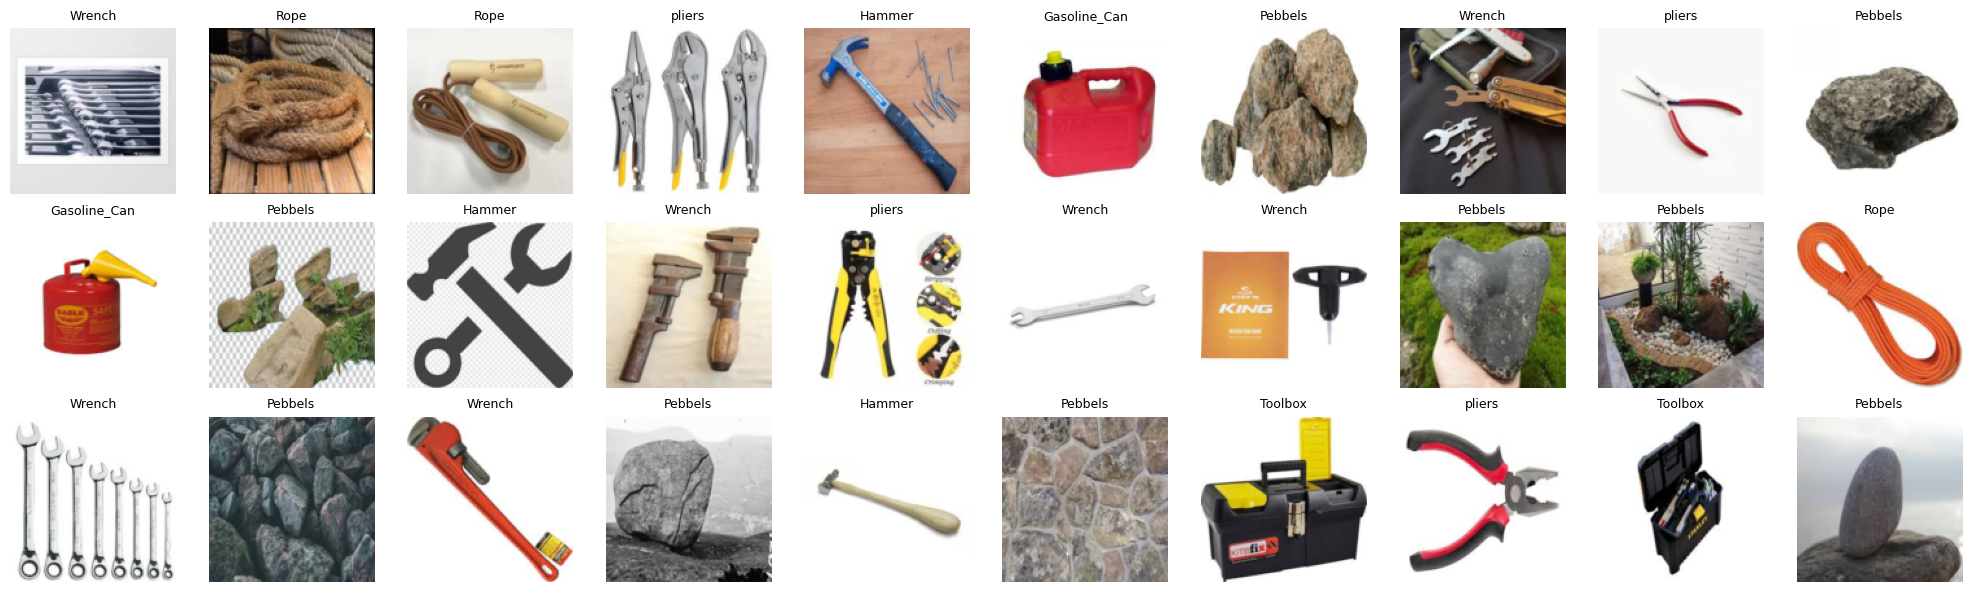

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
import matplotlib.pyplot as plt
import numpy as np

k = 0
plt.figure(figsize=(20, 6))  # wider for 3×10

for images, labels in train_loader:
    img = np.transpose(images[0].numpy(), (1, 2, 0))  # C,H,W -> H,W,C
    img = img / 2 + 0.5  # de-normalize to [0,1]

    plt.subplot(3, 10, k + 1)
    plt.axis('off')
    # show ground-truth label (use class name if available, else index)
    title = CLASSES[labels[0].item()] if 'CLASSES' in globals() else str(labels[0].item())
    plt.title(title, fontsize=9)
    plt.imshow(img)

    k += 1
    if k >= 30:
        break

plt.tight_layout()
plt.show()
#=============================================================================================#

### Part B-1(ii) [1pt EXPLORATORY]

How many training examples do we have for the combined classes?
What about validation examples?
What about test examples?

Plot the distribution of class labels in training/validation/test. Comment on whether the dataset is balanced or imbalanced.

Number of examples for: 
Training: 1152  |  Validation: 288  |  Test: 160


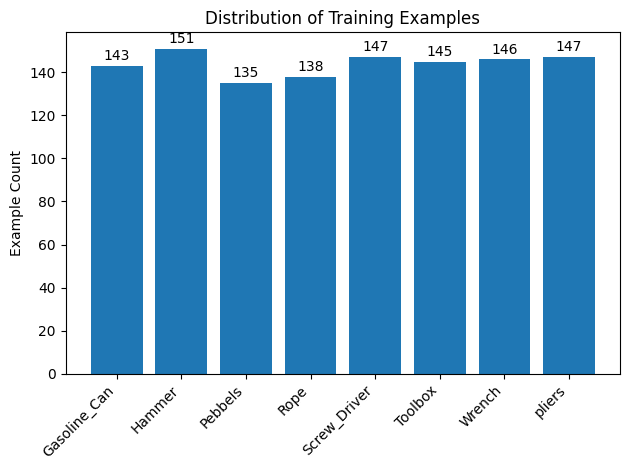

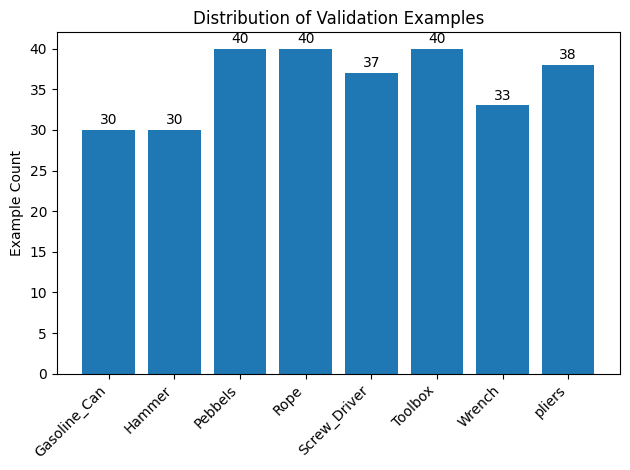

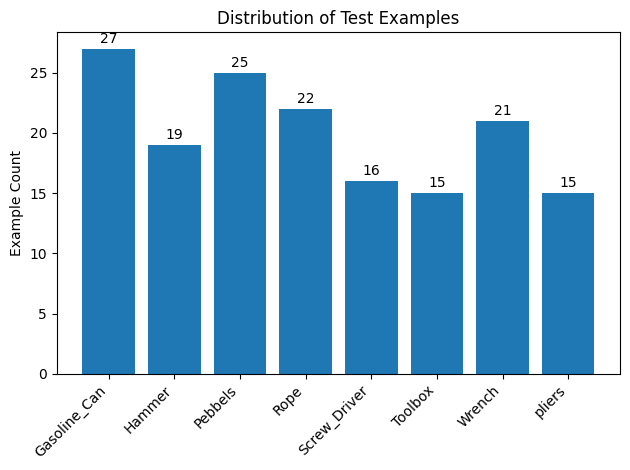

Train: min=135, max=151, imbalance_ratio=1.12 -> Balanced-ish
Val: min=30, max=40, imbalance_ratio=1.33 -> Balanced-ish
Test: min=15, max=27, imbalance_ratio=1.80 -> Imbalanced


In [ ]:
#========================================================================# COMPLETED CODE PART =========================================================================#

########################## Question 1: Number of examples ##########################
count_train = len(train_loader)
count_val = len(val_loader)
count_test = len(test_loader)

print(f"Number of examples for: \nTraining: {count_train}  |  Validation: {count_val}  |  Test: {count_test}")



########################## Question 2: Plot Distribution of Classes ##########################
def labels_from_subset(subset):
  '''
  Get labels from a subset for plotting distribution of classes
  '''
  base_imagefolder = subset.dataset     # get the ImageFolder datasets of the input subset
  idxs = subset.indices                # get the indice of the input subset in ImageFolder datasets
  targets = np.array(base_imagefolder.targets)     # get all lables of input subset
  return targets[idxs]                 # return labels of input subset by ImageFolder indice



def plot_dist(y, classes, title):
    """
    Plot distribution of classes with count labels on bars.
    """

    y = np.asarray(y)
    counts = np.bincount(y, minlength=len(classes))

    fig, ax = plt.subplots()
    ax.set_title(title)
    x = np.arange(len(classes))
    bars = ax.bar(x, counts)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylabel("Example Count")
    fig.tight_layout()

    ax.bar_label(bars, padding=2)
    plt.show()
    return counts



########################## Question 3: Balanced / Imbalanced Datasets Check ##########################

def balance_report(counts, split_name):
  '''
  Use min/max ratio to determine if dataset is balanced or imbalanced.
  '''

  ratio = counts.max() / counts.min()
  print(f"{split_name}: min={counts.min()}, max={counts.max()}, imbalance_ratio={ratio:.2f} "
        f"-> {'Imbalanced' if ratio > 1.5 else 'Balanced-ish'}")




# Identify labels for 3 datasets from original ImageFolder datasets
y_train = labels_from_subset(train_loader.dataset)
y_val   = labels_from_subset(val_loader.dataset)
y_test  = labels_from_subset(test_loader.dataset)


# Plot class distribution for 3 datasets
counts_train = plot_dist(y_train, classes, "Distribution of Training Examples")
counts_val   = plot_dist(y_val,   classes, "Distribution of Validation Examples")
counts_test  = plot_dist(y_test,  classes, "Distribution of Test Examples")


# Get the min/max ratios for 3 datasets to see if they are balanced
balance_report(counts_train, "Train")
balance_report(counts_val,   "Val")
balance_report(counts_test,  "Test")

#=========================================================================================================================================#


In [ ]:
'''There are 1152 training examples, 288 validation examples, and 288 test examples.

To identify if each datasets are balanced or not, I choose the min/max ratio, which is to divide the maximum count of a class by the minumum count of a class.
If the min/max ratio is over 1.5, then this distribution if imbalanced because  one class has far more samples than the smallest class, so learning will bias towards the majority.

Based on this approach, the training dataset is balanced; validation dataset is balanced; and test dataset is imbalanced.
'''

## Part B-2. Training

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [ ]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 29 * 29, 32)
        self.fc2 = nn.Linear(32, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 29 * 29)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 31 * 31, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 31 * 31)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
small_net = SmallNet()
large_net = LargeNet()

### Part B-2(i) [1pt EXPLORATORY]

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values.

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

In [ ]:
# TO BE COMPLETED
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

n_param_smallnet = count_parameters(small_net)
n_param_largenet = count_parameters(large_net)

print(f"The number of parameter of Small Net ={n_param_smallnet:,},\nThe number of parameter of Large Net ={n_param_largenet:,}")

The number of parameter of Small Net =38,588,
The number of parameter of Large Net =271,056


In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The number of parameter of Small Net =38,588,
The number of parameter of Large Net =271,056

'''

### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [ ]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on an 8-class classification problem
    target_classes = ["Gasoline_Can", "Hammer", "Pebbels", "pliers",
                      "Rope", "Screw_Driver", "Toolbox", "Wrench"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible results
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            data_dir='/content/mechanical_tools/mechanical_tools',  # Ensure this is where your dataset is stored
            seed=1000, batch_size=batch_size)

    # Make sure the classes are as expected
    assert len(classes) == 8, "The dataset should have exactly 8 classes."
    ########################################################################
    # Define the Loss function and optimizer
    # Use CrossEntropyLoss for multi-class classification
    criterion = nn.CrossEntropyLoss()  # Change to CrossEntropyLoss for multi-class
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/accuracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # Loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)  # No need to normalize labels here for CrossEntropyLoss
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            _, predicted = torch.max(outputs, 1)  # Get the class with the highest probability
            total_train_err += (predicted != labels).sum().item()  # Count errors
            total_train_loss += loss.item()
            total_epoch += len(labels)

        # Calculate error and loss for the training and validation set
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i + 1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)

        # Print stats for the current epoch
        print(f"Epoch {epoch + 1}: Train err: {train_err[epoch]:.4f}, Train loss: {train_loss[epoch]:.4f} | "
              f"Validation err: {val_err[epoch]:.4f}, Validation loss: {val_loss[epoch]:.4f}")

        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)

    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total time elapsed: {elapsed_time:.2f} seconds")

    # Write the train/test loss/error into CSV files for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt(f"{model_path}_train_err.csv", train_err)
    np.savetxt(f"{model_path}_train_loss.csv", train_loss)
    np.savetxt(f"{model_path}_val_err.csv", val_err)
    np.savetxt(f"{model_path}_val_loss.csv", val_loss)


### Part B-2(ii) [0.5pt EXPLORATORY]

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on.

What are the default values of the parameters `batch_size`, `learning_rate`,
and `num_epochs`?

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The default values of the parameters batch_size = 64, learning_rate = 0.01, and num_epochs = 30.

'''

### Part B-2(iii) [0.5pt EXPLORATORY]
What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

File 1: model_small_net_bs64_lr0.01_epoch4_train_err.csv
Content: the training error count as a percentage over the total number of training examples.

File 2: model_small_net_bs64_lr0.01_epoch4_train_loss.csv
Content: the average training loss of all batches in an epoch of training examples.

File 3: model_small_net_bs64_lr0.01_epoch4_val_err.csv
Content: the validation error count as a percentage over the total number of validation examples.

File 4: model_small_net_bs64_lr0.01_epoch4_val_loss.csv
Content: the average training loss of all batches in an epoch of training examples.


'''

### Part B-2(iv) [0.5pt EXPLORATORY]
Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights)
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive
so that the files generated by `train_net` gets saved. We will be using
these files in the parts that follow.
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?

In [ ]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the assignment locally, you
# can comment out this code.

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
train_net(small_net)
train_net(large_net)
#=============================================================================================#

Epoch 1: Train err: 0.7326, Train loss: 1.8535 | Validation err: 0.5972, Validation loss: 1.6587
Epoch 2: Train err: 0.5538, Train loss: 1.5837 | Validation err: 0.5590, Validation loss: 1.5533
Epoch 3: Train err: 0.4887, Train loss: 1.3460 | Validation err: 0.5799, Validation loss: 1.5816
Epoch 4: Train err: 0.4366, Train loss: 1.2206 | Validation err: 0.5521, Validation loss: 1.5546
Epoch 5: Train err: 0.3915, Train loss: 1.0982 | Validation err: 0.5590, Validation loss: 1.6079
Epoch 6: Train err: 0.3125, Train loss: 0.9125 | Validation err: 0.5451, Validation loss: 1.6600
Epoch 7: Train err: 0.2613, Train loss: 0.7829 | Validation err: 0.5417, Validation loss: 1.7767
Epoch 8: Train err: 0.2240, Train loss: 0.6713 | Validation err: 0.6076, Validation loss: 1.9462
Epoch 9: Train err: 0.1832, Train loss: 0.5816 | Validation err: 0.5799, Validation loss: 2.2432
Epoch 10: Train err: 0.1094, Train loss: 0.3823 | Validation err: 0.5729, Validation loss: 2.2387
Epoch 11: Train err: 0.0773, 

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

After running multiple time of the training function, I notice:
the small net takes around 2 to 3 minutes to train, while the large net takes 4 to 5 minutes to train.
The large net takes longer to train, because it has larger number of parameters per batch, which also causes a heavier back propogation calculation

'''

### Part B-2(v) [0.5pt EXPLORATORY]
Use the function `plot_training_curve` to display the trajectory of the
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.

In [ ]:
model_path_small_net = get_model_name("small", batch_size=64, learning_rate=0.01, epoch=29)
model_path_large_net = get_model_name("large", batch_size=64, learning_rate=0.01, epoch=29)

Small Net Plotting
----------------------------------------------------------------------------------------------------


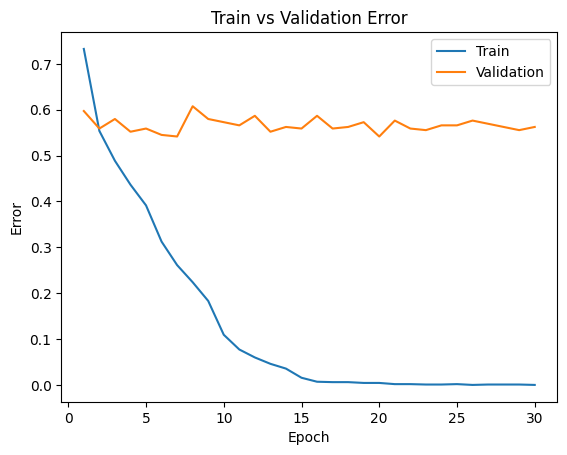

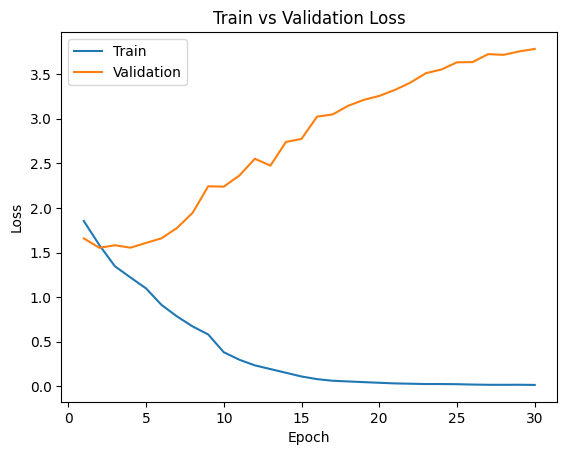

Large Net Plotting
----------------------------------------------------------------------------------------------------


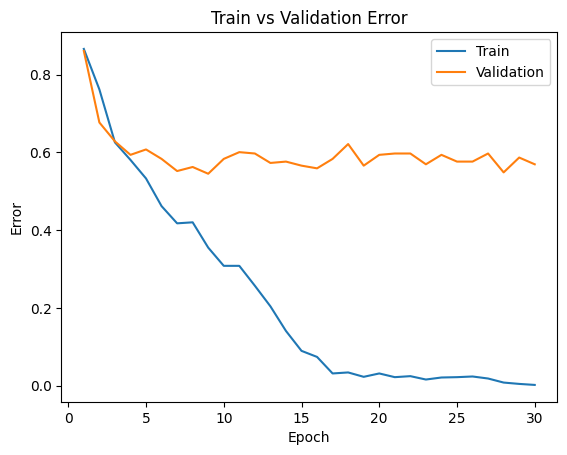

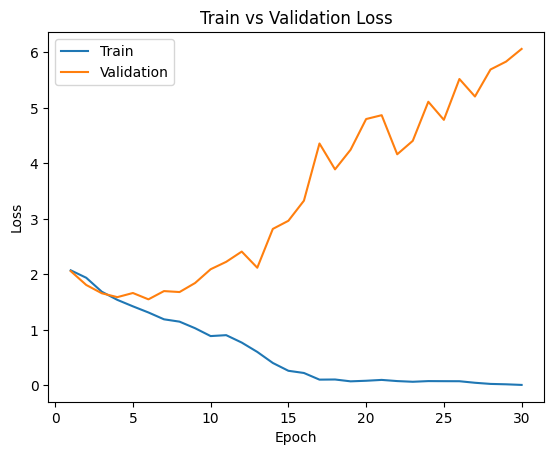

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

############# Small Net Plotting ################
print(f"\033[1mSmall Net Plotting\033[0m")      # bold
print("-" * 100)
plot_training_curve(model_path_small_net)

############# Large Net Plotting ################
print(f"\033[1mLarge Net Plotting\033[0m")      # bold
print("-" * 100)
plot_training_curve(model_path_large_net)

#=============================================================================================#

### Part B-2(vi) [0.5pt EXPLORATORY]
Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

In shape-wise, the large net and small net models imply similar shapes in both error rate chart and loss chart, with both net models show overfitting.
More specifically, it's because both error rate and loss of training datasets coverge to 0 while that of validation datasets keeps increasing.

In the aspect of value, small net model converges quicklier, even though the validation error are eventually close at around 60% for both net modesl.

Also, there is an obvious difference is that the loss in large model doubles to that of small model, which is 6 to 3. It implies that the large net model is confident in wrong prediction.

'''

## Part B-3. Optimization Parameters

For this section, we will work with `large_net` only.

### Part B-3(i) [0.5pt EXPLORATORY]
Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.

In [ ]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
train_net(large_net, learning_rate=0.001)
#=============================================================================================#

Epoch 1: Train err: 0.8741, Train loss: 2.0835 | Validation err: 0.8160, Validation loss: 2.0727
Epoch 2: Train err: 0.8411, Train loss: 2.0686 | Validation err: 0.8125, Validation loss: 2.0584
Epoch 3: Train err: 0.7691, Train loss: 2.0458 | Validation err: 0.7500, Validation loss: 2.0286
Epoch 4: Train err: 0.7535, Train loss: 1.9948 | Validation err: 0.8021, Validation loss: 1.9667
Epoch 5: Train err: 0.7378, Train loss: 1.8968 | Validation err: 0.7604, Validation loss: 1.8681
Epoch 6: Train err: 0.7179, Train loss: 1.7783 | Validation err: 0.6667, Validation loss: 1.7636
Epoch 7: Train err: 0.6267, Train loss: 1.6667 | Validation err: 0.6389, Validation loss: 1.6932
Epoch 8: Train err: 0.6172, Train loss: 1.6195 | Validation err: 0.6632, Validation loss: 1.7056
Epoch 9: Train err: 0.5911, Train loss: 1.5534 | Validation err: 0.6562, Validation loss: 1.6510
Epoch 10: Train err: 0.5573, Train loss: 1.5159 | Validation err: 0.5903, Validation loss: 1.6271
Epoch 11: Train err: 0.5503, 

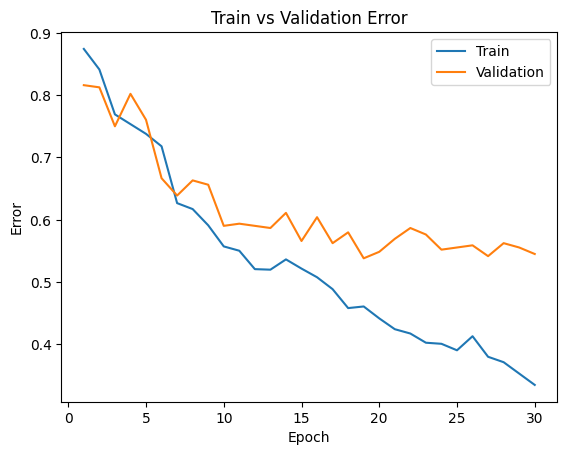

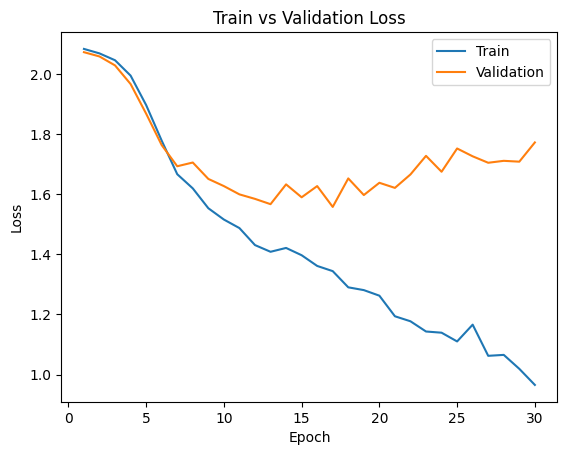

In [ ]:
plot_training_curve(get_model_name("large", batch_size=64, learning_rate=0.001, epoch=29))

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

With a lower learning rate 0.001, the training time remians the same with a lower loss value, dropping from 6 to below 1.8, which proved the improved prediction performance.

Even though the error rate of the validation dataset doesn't decrease too much (still coverges to 60%), the lower loss rate means that the model now has a higher probability to predict correctly.


'''

### Part B-3(ii) [0.5pt EXPLORATORY]
Train `large_net` with all default parameters, except set `learning_rate=0.1`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.

Epoch 1: Train err: 0.8142, Train loss: 2.0502 | Validation err: 0.7882, Validation loss: 3.0274
Epoch 2: Train err: 0.8655, Train loss: 2.1937 | Validation err: 0.8958, Validation loss: 2.0920
Epoch 3: Train err: 0.8550, Train loss: 2.0767 | Validation err: 0.8160, Validation loss: 2.0154
Epoch 4: Train err: 0.8637, Train loss: 2.7986 | Validation err: 0.8542, Validation loss: 2.0856
Epoch 5: Train err: 0.8863, Train loss: 2.0838 | Validation err: 0.8681, Validation loss: 2.0794
Epoch 6: Train err: 0.8707, Train loss: 2.0824 | Validation err: 0.8681, Validation loss: 2.0842
Epoch 7: Train err: 0.8872, Train loss: 2.0829 | Validation err: 0.8576, Validation loss: 2.0797
Epoch 8: Train err: 0.8837, Train loss: 2.0828 | Validation err: 0.8681, Validation loss: 2.0805
Epoch 9: Train err: 0.8837, Train loss: 2.0829 | Validation err: 0.8785, Validation loss: 2.0821
Epoch 10: Train err: 0.8750, Train loss: 2.0876 | Validation err: 0.8681, Validation loss: 2.0818
Epoch 11: Train err: 0.8880, 

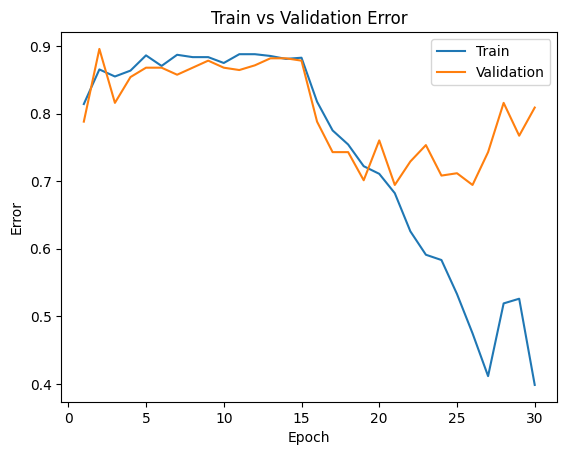

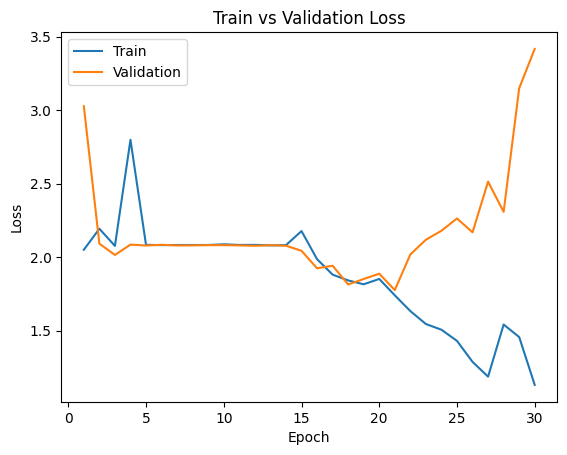

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
large_net = LargeNet()
train_net(large_net, learning_rate=0.1)
plot_training_curve(get_model_name("large", batch_size=64, learning_rate=0.1, epoch=29))
#=============================================================================================#

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

With a higher learning rate 0.1, the training time remains but the prediction accuracy is much lower. More specifically, the error rate increases to around 70% to 80%, and the loss doesn't converge at all.

This is mainly because the step size is too big to identify the spot with the minimum loss, a large learning rate may cause the model to miss the right point and lower prediction accuracy.



'''

### Part B-3(iii) [0.5pt EXPLORATORY]

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.

Epoch 1: Train err: 0.8802, Train loss: 2.0861 | Validation err: 0.8542, Validation loss: 2.0762
Epoch 2: Train err: 0.8663, Train loss: 2.0790 | Validation err: 0.8125, Validation loss: 2.0685
Epoch 3: Train err: 0.8038, Train loss: 2.0663 | Validation err: 0.7917, Validation loss: 2.0591
Epoch 4: Train err: 0.7760, Train loss: 2.0494 | Validation err: 0.7917, Validation loss: 2.0385
Epoch 5: Train err: 0.7769, Train loss: 2.0102 | Validation err: 0.7812, Validation loss: 1.9907
Epoch 6: Train err: 0.7648, Train loss: 1.9540 | Validation err: 0.7986, Validation loss: 1.9194
Epoch 7: Train err: 0.7587, Train loss: 1.8556 | Validation err: 0.7535, Validation loss: 1.8497
Epoch 8: Train err: 0.7205, Train loss: 1.7598 | Validation err: 0.7014, Validation loss: 1.7964
Epoch 9: Train err: 0.6562, Train loss: 1.6938 | Validation err: 0.6771, Validation loss: 1.7465
Epoch 10: Train err: 0.6241, Train loss: 1.6161 | Validation err: 0.6701, Validation loss: 1.7283
Epoch 11: Train err: 0.6137, 

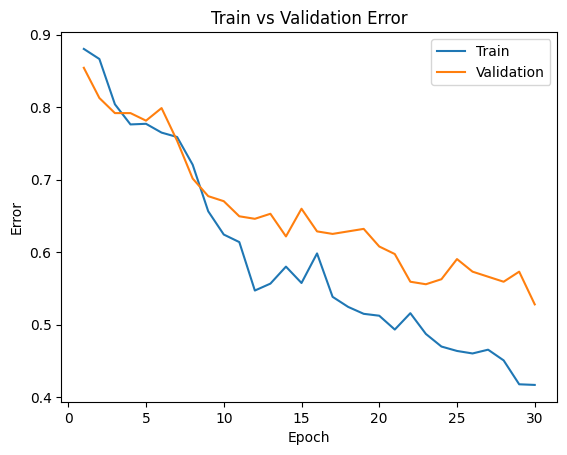

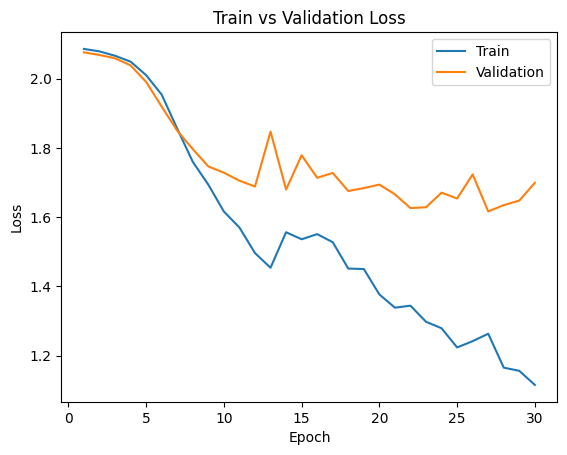

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
large_net = LargeNet()
train_net(large_net, batch_size=512)
plot_training_curve(get_model_name("large", batch_size=512, learning_rate=0.01, epoch=29))
#=============================================================================================#

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

With a higher batch size 512, the training time increases by 20% to around 5 - 6 minutes, but the loss reduces a bit, and the error rate remians the same.

'''

### Part B-3(iv) [0.5pt EXPLORATORY]

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.

Epoch 1: Train err: 0.7613, Train loss: 1.9277 | Validation err: 0.7986, Validation loss: 1.9890
Epoch 2: Train err: 0.7214, Train loss: 1.8156 | Validation err: 0.7257, Validation loss: 1.7808
Epoch 3: Train err: 0.6858, Train loss: 1.7587 | Validation err: 0.7326, Validation loss: 1.8193
Epoch 4: Train err: 0.6910, Train loss: 1.7433 | Validation err: 0.6736, Validation loss: 1.7230
Epoch 5: Train err: 0.6415, Train loss: 1.6779 | Validation err: 0.6181, Validation loss: 1.7089
Epoch 6: Train err: 0.5477, Train loss: 1.4951 | Validation err: 0.6285, Validation loss: 1.6931
Epoch 7: Train err: 0.4557, Train loss: 1.2767 | Validation err: 0.6493, Validation loss: 1.9106
Epoch 8: Train err: 0.3611, Train loss: 0.9948 | Validation err: 0.6354, Validation loss: 1.9044
Epoch 9: Train err: 0.2700, Train loss: 0.7904 | Validation err: 0.6354, Validation loss: 2.3977
Epoch 10: Train err: 0.1806, Train loss: 0.5530 | Validation err: 0.6354, Validation loss: 2.9978
Epoch 11: Train err: 0.1476, 

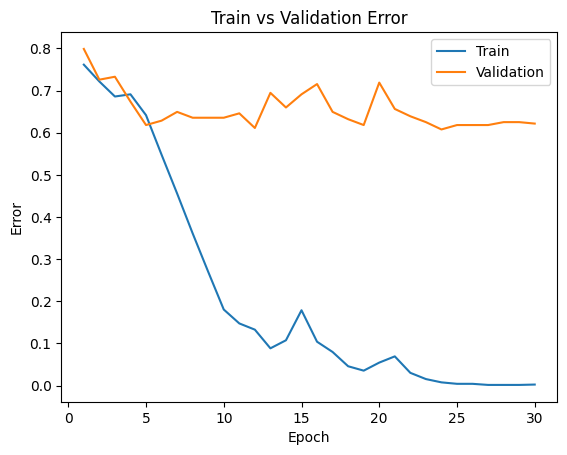

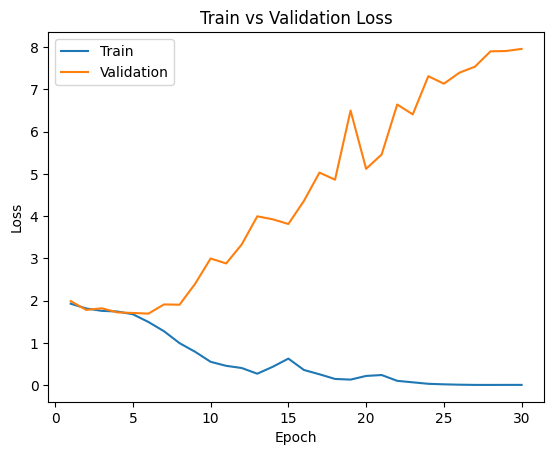

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
large_net = LargeNet()
train_net(large_net, batch_size=16)
plot_training_curve(get_model_name("large", batch_size=16, learning_rate=0.01, epoch=29))
#=============================================================================================#

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

With a lower batch size 16, the training time remains at 4-5 minutes but the loss is much higher. More specifically, the loss increased from 3 to 8.
This is mainly because the smaller batch size brings more noise so that makes the model harder to converge and oscillate.

'''

## Part B-4. Hyperparameter Search

### Part B-4(i) [0.5pt EXPLORATORY]

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

I choose to use large net model with batch size 256 and learning rate 0.001.

For learning rate, the above plots showed that the lower the learning rate is, the much smaller the loss is. However, I don't use a too small learning rate because it will converge slowly. Then I select step size as 0.001.

For batch size, the reason is that I notice that a huge increase in batch size only reduces a bit of loss, but will take longer to train. Thus, I choose a midium batch size to balance the trade-off between training time and loss.


'''

### Part B-4(ii) [0.5pt EXPLORATORY]

Train the model with the hyperparameters you chose in part(i), and include the training curve.

Epoch 1: Train err: 0.8802, Train loss: 2.0866 | Validation err: 0.8507, Validation loss: 2.0791
Epoch 2: Train err: 0.8802, Train loss: 2.0850 | Validation err: 0.8542, Validation loss: 2.0768
Epoch 3: Train err: 0.8785, Train loss: 2.0816 | Validation err: 0.8438, Validation loss: 2.0735
Epoch 4: Train err: 0.8394, Train loss: 2.0767 | Validation err: 0.8090, Validation loss: 2.0700
Epoch 5: Train err: 0.8125, Train loss: 2.0738 | Validation err: 0.8299, Validation loss: 2.0657
Epoch 6: Train err: 0.8134, Train loss: 2.0685 | Validation err: 0.8333, Validation loss: 2.0610
Epoch 7: Train err: 0.8203, Train loss: 2.0638 | Validation err: 0.8125, Validation loss: 2.0560
Epoch 8: Train err: 0.8134, Train loss: 2.0579 | Validation err: 0.7812, Validation loss: 2.0497
Epoch 9: Train err: 0.7760, Train loss: 2.0502 | Validation err: 0.7569, Validation loss: 2.0421
Epoch 10: Train err: 0.7543, Train loss: 2.0411 | Validation err: 0.7604, Validation loss: 2.0331
Epoch 11: Train err: 0.7448, 

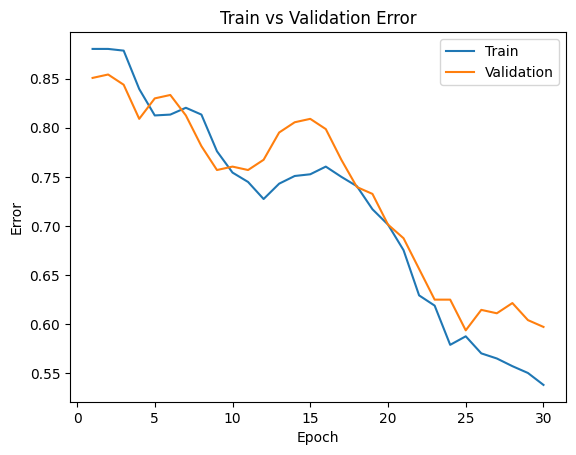

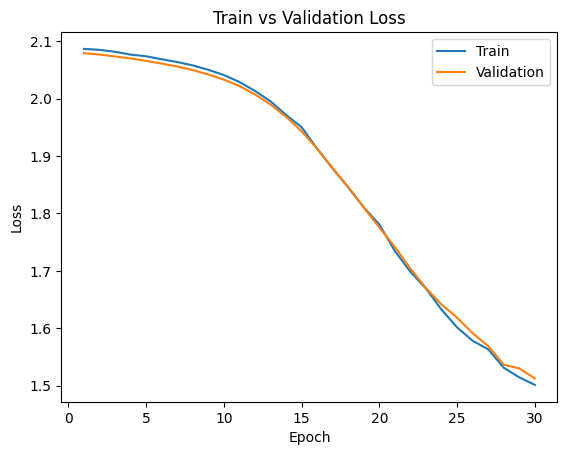

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
large_net = LargeNet()
train_net(large_net, batch_size=256, learning_rate=0.001)
plot_training_curve(get_model_name("large", batch_size=256, learning_rate=0.001, epoch=29))
#=============================================================================================#

### Part B-4(iii) [0.5pt EXPLORATORY]
Based on your result from Part(i), suggest another set of hyperparameter values to try.
Justify your choice.

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

Based on results in Part(i), I see a drop in loss from 1.8 to 1.5 and constant error rate 60%, which indicates a better validation accuracy, but the training time is a bit of long.

Since reducing batch size will lower the training time without increasing loss drastically, I decide to lower the batch size to 128 and same learning rate 0.001.


'''

### Part B-4(iv) [0.5pt EXPLORATORY]

Train the model with the hyperparameters you chose in part(iii), and include the training curve.

Epoch 1: Train err: 0.8802, Train loss: 2.0857 | Validation err: 0.8542, Validation loss: 2.0777
Epoch 2: Train err: 0.8637, Train loss: 2.0803 | Validation err: 0.8194, Validation loss: 2.0724
Epoch 3: Train err: 0.8090, Train loss: 2.0730 | Validation err: 0.8125, Validation loss: 2.0645
Epoch 4: Train err: 0.7986, Train loss: 2.0637 | Validation err: 0.8090, Validation loss: 2.0561
Epoch 5: Train err: 0.7856, Train loss: 2.0521 | Validation err: 0.7778, Validation loss: 2.0440
Epoch 6: Train err: 0.7509, Train loss: 2.0356 | Validation err: 0.7639, Validation loss: 2.0262
Epoch 7: Train err: 0.7457, Train loss: 2.0098 | Validation err: 0.7882, Validation loss: 1.9992
Epoch 8: Train err: 0.7535, Train loss: 1.9725 | Validation err: 0.8056, Validation loss: 1.9591
Epoch 9: Train err: 0.7604, Train loss: 1.9203 | Validation err: 0.7882, Validation loss: 1.9093
Epoch 10: Train err: 0.7517, Train loss: 1.8608 | Validation err: 0.7500, Validation loss: 1.8568
Epoch 11: Train err: 0.7127, 

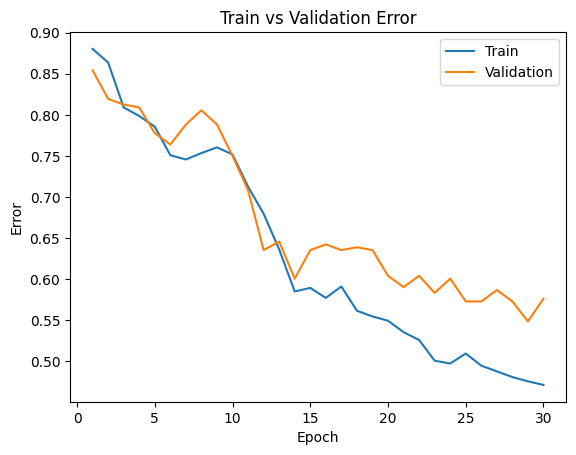

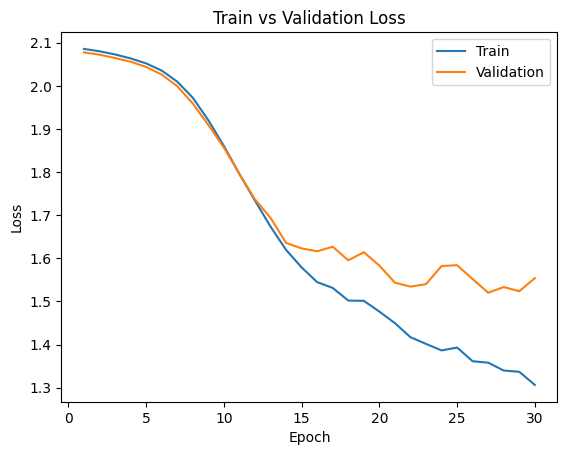

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#large_net = LargeNet()
train_net(large_net, batch_size=128, learning_rate=0.001)
plot_training_curve(get_model_name("large", batch_size=128, learning_rate=0.001, epoch=29))
#=============================================================================================#


### Part B-4(v) [1pt EXPLORATORY]


Using the models you trained in earlier subparts of Part B-4, plot a heatmap of validation errors across at least two hyperparameters (e.g., batch size vs. learning rate). Make sure to select at least two values for each hyperparameter and train the model for all combinations. The rows correspond to different batch sizes, the columns correspond to different learning rates, and the cell values are the validation errors.

Briefly explain any trends you observe and what they suggest about the effect of these hyperparameters.


 Hint: A heatmap is simply a color-coded grid where each cell’s color represents a numerical value. For example, here’s a small heatmap created with random values:

  `random_vals = np.random.rand(3, 4)`

  `sns.heatmap(random_vals, annot=True, fmt=".2f")`
  
  `plt.title("Example Heatmap with Random Values")`
  
  `plt.show()`




=== Training: bs=512, lr=0.01 ===
Epoch 1: Train err: 0.8828, Train loss: 2.0865 | Validation err: 0.8958, Validation loss: 2.0801
Epoch 2: Train err: 0.8811, Train loss: 2.0836 | Validation err: 0.8785, Validation loss: 2.0782
Epoch 3: Train err: 0.8724, Train loss: 2.0842 | Validation err: 0.8785, Validation loss: 2.0767
Epoch 4: Train err: 0.8689, Train loss: 2.0714 | Validation err: 0.8750, Validation loss: 2.0739
Epoch 5: Train err: 0.8759, Train loss: 2.0689 | Validation err: 0.8889, Validation loss: 2.0688
Epoch 6: Train err: 0.8733, Train loss: 2.0624 | Validation err: 0.8854, Validation loss: 2.0633
Epoch 7: Train err: 0.8724, Train loss: 2.0560 | Validation err: 0.8854, Validation loss: 2.0520
Epoch 8: Train err: 0.8733, Train loss: 2.0256 | Validation err: 0.8542, Validation loss: 2.0274
Epoch 9: Train err: 0.8325, Train loss: 1.9946 | Validation err: 0.8750, Validation loss: 2.0098
Epoch 10: Train err: 0.8255, Train loss: 1.9738 | Validation err: 0.8542, Validation loss: 1

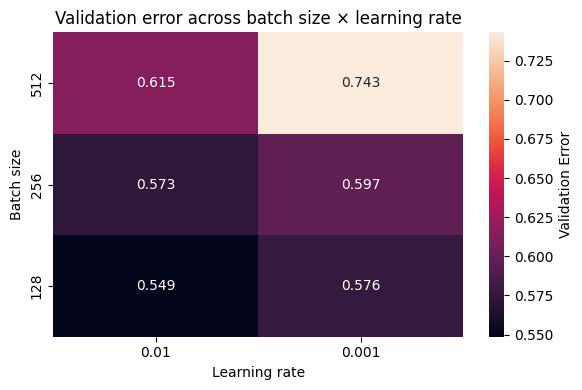

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#
import seaborn as sns


batch_sizes = [512, 256, 128]            # rows
learning_rates = [0.01, 0.001]      # columns
n_epoch = 30
model_ctor = LargeNet                  # net model

# Set Seed
torch.manual_seed(1000)
np.random.seed(1000)

# Heatmap Plotting
val_grid = np.zeros((len(batch_sizes), len(learning_rates)), dtype=float)

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        # Train net model with each combo of "learning rate" and "batch size"
        net = model_ctor()
        print(f"\n=== Training: bs={bs}, lr={lr} ===")
        train_net(net, batch_size=bs, learning_rate=lr, num_epochs=n_epoch)

        # Get model name for file extraction
        prefix = get_model_name(net.name, bs, lr, n_epoch-1)

        # Read validation error file & Get the last value for heatmap
        val_err_curve = np.loadtxt(f"{prefix}_val_err.csv")
        val_grid[i, j] = float(val_err_curve[-1])


# Heatmap Plotting
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    val_grid, annot=True, fmt=".3f",
    xticklabels=[str(x) for x in learning_rates],
    yticklabels=[str(x) for x in batch_sizes],
    cbar_kws={"label": "Validation Error"}
)
ax.set_xlabel("Learning rate")
ax.set_ylabel("Batch size")
ax.set_title("Validation error across batch size × learning rate")
plt.tight_layout()
plt.show()

#=============================================================================================#


In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The best hyperparameter combo is batch size=128 and learning rate=0.01.

The reason is that larger batch size means that more parameters are updated each epoch which is noiser, so in this case, the smallest batch size performs the best.

In terms of learning rate, since we only have 30 epoches, learning rate = 0.001 is too small to converge within 30 epoches, so the learning rate = 0.01 is better in this case.

I suggest using batch size=128 and learning rate=0.01 to train the model. However, if we have larger number of epoches, then choose learning rate = 0.001, becasue it's stable and have enough epoches to converge.

'''

## Part B-5. Evaluating the Best Model


### Part B-5(i) [2pt MODEL]

Summarize in a table the results achieved on training and validation on all your model selections in all parts. This includes choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`,
**and the epoch number**. Hint: you can import the Pandas module to create tables.


Then upon reviewing the results choose your **best** model and load the model checkpoint. You can modify the code below to load your chosen set of weights to the model object `net`.

In [ ]:
net = SmallNet
model_path = get_model_name(net.name, batch_size=512, learning_rate=0.01, epoch=30)
state = torch.load(model_path)
net.load_state_dict(state)

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

# ====== Train model with those hyperparameters that haven't been trained ======

# Set seeds for replication
torch.manual_seed(1000)
np.random.seed(1000)
print("== Train SmallNet ==")
net = SmallNet(); train_net(net, batch_size=128, learning_rate=0.01,  num_epochs=30)
net = SmallNet(); train_net(net, batch_size=256, learning_rate=0.01,  num_epochs=30)
net = SmallNet(); train_net(net, batch_size=512, learning_rate=0.01,  num_epochs=30)

net = SmallNet(); train_net(net, batch_size=128, learning_rate=0.001, num_epochs=30)
net = SmallNet(); train_net(net, batch_size=256, learning_rate=0.001, num_epochs=30)
net = SmallNet(); train_net(net, batch_size=512, learning_rate=0.001, num_epochs=30)

print("== Train LargeNet ==\nAlready trained large net model above so no training here")
# net = LargeNet(); train_net(net, batch_size=128, learning_rate=0.01,  num_epochs=30)
# net = LargeNet(); train_net(net, batch_size=256, learning_rate=0.01,  num_epochs=30)
# net = LargeNet(); train_net(net, batch_size=512, learning_rate=0.01,  num_epochs=30)

# net = LargeNet(); train_net(net, batch_size=128, learning_rate=0.001, num_epochs=30)
# net = LargeNet(); train_net(net, batch_size=256, learning_rate=0.001, num_epochs=30)
# net = LargeNet(); train_net(net, batch_size=512, learning_rate=0.001, num_epochs=30)

== Train SmallNet ==
Epoch 1: Train err: 0.7795, Train loss: 1.9640 | Validation err: 0.6840, Validation loss: 1.8072
Epoch 2: Train err: 0.6441, Train loss: 1.6972 | Validation err: 0.6389, Validation loss: 1.6920
Epoch 3: Train err: 0.5703, Train loss: 1.5158 | Validation err: 0.5972, Validation loss: 1.5761
Epoch 4: Train err: 0.5165, Train loss: 1.3958 | Validation err: 0.5868, Validation loss: 1.5530
Epoch 5: Train err: 0.4514, Train loss: 1.3088 | Validation err: 0.6042, Validation loss: 1.5221
Epoch 6: Train err: 0.4236, Train loss: 1.1952 | Validation err: 0.5243, Validation loss: 1.5569
Epoch 7: Train err: 0.3750, Train loss: 1.1163 | Validation err: 0.5174, Validation loss: 1.5351
Epoch 8: Train err: 0.3524, Train loss: 1.0094 | Validation err: 0.5486, Validation loss: 1.5848
Epoch 9: Train err: 0.2943, Train loss: 0.8643 | Validation err: 0.5347, Validation loss: 1.6010
Epoch 10: Train err: 0.2292, Train loss: 0.7567 | Validation err: 0.5451, Validation loss: 1.6864
Epoch 11

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

import os, re, glob
import pandas as pd

# Define directory folder
BASE_DIR = os.getcwd()

# match file names
pat = re.compile(r"model_(?P<name>\w+)_bs(?P<bs>\d+)_lr(?P<lr>[-+eE\d\.]+)_epoch(?P<epoch>\d+)")

rows = []
for f in glob.glob(os.path.join(BASE_DIR, "model_*_val_err.csv")):
    m = pat.search(os.path.basename(f))
    if not m:
        continue
    name  = m.group("name")
    bs    = int(m.group("bs"))
    lr    = float(m.group("lr"))
    epoch = int(m.group("epoch"))
    prefix = os.path.join(BASE_DIR, f"model_{name}_bs{bs}_lr{lr}_epoch{epoch}")

    try:
        # Read the last value from the last epoch to display in output table
        train_err  = float(np.atleast_1d(np.loadtxt(prefix + "_train_err.csv"))[-1])
        train_loss = float(np.atleast_1d(np.loadtxt(prefix + "_train_loss.csv"))[-1])
        val_err    = float(np.atleast_1d(np.loadtxt(prefix + "_val_err.csv"))[-1])
        val_loss   = float(np.atleast_1d(np.loadtxt(prefix + "_val_loss.csv"))[-1])
    except OSError:
        # to handle non-existing file name
        continue

    rows.append({
        "model": name,
        "batch_size": bs,
        "learning_rate": lr,
        "epoch": epoch,  # index of last epoch
        "train_err_final": train_err,
        "train_loss_final": train_loss,
        "val_err_final": val_err,
        "val_loss_final": val_loss,
        "run_prefix": prefix
    })

# Display output table
df = pd.DataFrame(rows)

# Sort output table first by validation error rate, then by validation loss
df_sorted = df.sort_values(["val_err_final", "val_loss_final"]).reset_index(drop=True)
df_sorted = df_sorted[df_sorted['epoch']==29]
display(df_sorted)

# Print the best model
best = df_sorted.iloc[0]
print("\nBest run:", best.to_dict())
#=============================================================================================#

,model,batch_size,learning_rate,epoch,train_err_final,train_loss_final,val_err_final,val_loss_final,run_prefix
0,small,512,0.010,29,0.230035,0.744187,0.531250,1.754631,/content/model_small_bs512_lr0.01_epoch29
1,large,64,0.001,29,0.335069,0.965647,0.545139,1.772406,/content/model_large_bs64_lr0.001_epoch29
2,large,128,0.010,29,0.026042,0.096802,0.548611,4.215088,/content/model_large_bs128_lr0.01_epoch29
3,small,256,0.010,29,0.054688,0.284184,0.555556,1.968421,/content/model_small_bs256_lr0.01_epoch29
4,small,128,0.001,29,0.370660,1.082122,0.559028,1.458179,/content/model_small_bs128_lr0.001_epoch29
5,small,64,0.010,29,0.000000,0.015694,0.562500,3.783243,/content/model_small_bs64_lr0.01_epoch29
6,small,128,0.010,29,0.003472,0.049985,0.569444,2.886582,/content/model_small_bs128_lr0.01_epoch29
7,large,64,0.010,29,0.001736,0.009544,0.569444,6.060222,/content/model_large_bs64_lr0.01_epoch29
8,large,256,0.010,29,0.128472,0.374329,0.572917,2.633994,/content/model_large_bs256_lr0.01_epoch29
9,large,128,0.001,29,0.471354,1.306324,0.576389,1.553994,/content/model_large_bs128_lr0.001_epoch29



Best run: {'model': 'small', 'batch_size': 512, 'learning_rate': 0.01, 'epoch': 29, 'train_err_final': 0.2300347222222222, 'train_loss_final': 0.7441874345143636, 'val_err_final': 0.53125, 'val_loss_final': 1.7546306848526, 'run_prefix': '/content/model_small_bs512_lr0.01_epoch29'}


### Part B-5(ii) [4pt DISCUSSION]

Justify your choice of model from Part (i).

In [ ]:
'''

===================================== MY ANSWER BELOW =====================================

The best model is large net model with batch size 512 and learning rate 0.01. There are 3 reasons to justify:

1. This run has the lowest validation error rate (i.e. 0.5313) among all others.

2. More generalized - because the training error rate (i.e. 0.23) isn't close to 0 that implies there is no overfitting for this mode

3. Validation loss is relatively low - compare to the second and third ranked models, the validation loss is lower, which means this model is more confident giving the accurate prefiction

Thus, I think large net model with batch size 512 and learning rate 0.01 is the best model.


'''

### Part B-5(iii) [2pt RESULT]

Using the helper code in Part 0, any code from lecture notes, or any code that you write:

- Compute and report the **test classification error** for your chosen model.


- For 5 test images, print the true label of the image, and report the top-3 predicted classes with their probabilities.
(“Top-3” means the three classes with the highest predicted probabilities, showing the model’s first, second, and third best guesses.)
Comment on whether the probabilities reflect the model’s confidence (e.g., does it give a very high probability to a wrong class, or spread probabilities when uncertain?).


In [ ]:
# If you use the `evaluate` function provided in part 0, you will need to
# set batch_size > 1
train_loader, val_loader, test_loader, classes = get_data_loader(
    data_dir=data_dir, seed=1000,
    batch_size=64)

Test classification error: 0.4813 (48.12%)
Test loss: 1.5883


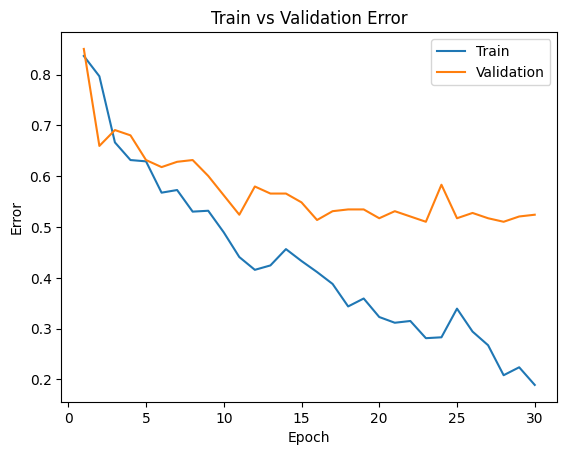

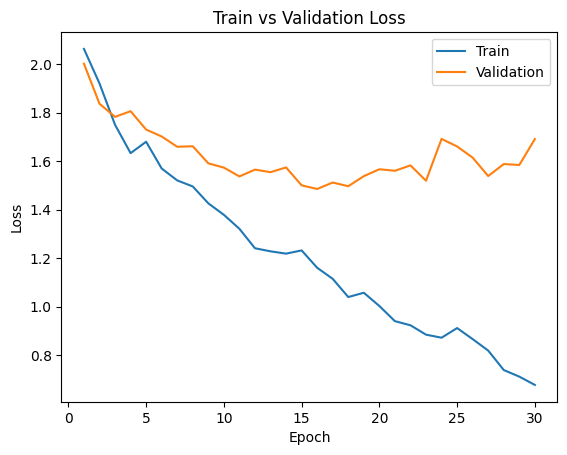

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

import torch
import torch.nn as nn

# ===== 1) Set the best model hyperparameters & Identify File Name =====
best_model_name = "small"
best_bs = 512
best_lr = 0.01
best_epoch = 29
data_dir = "/content/mechanical_tools/mechanical_tools"
best_ckpt = f"/content/model_{best_model_name}_bs{best_bs}_lr{best_lr}_epoch{best_epoch-1}"


# ===== 3) build prefix & load model =====
prefix = get_model_name(best_model_name, best_bs, best_lr, best_epoch)  # e.g., model_small_bs512_lr0.01_epoch29
net = SmallNet()
net.load_state_dict(torch.load(prefix, map_location="cpu"))
net.eval()

# ===== 5) Evaludate Error Rate =====
criterion = nn.CrossEntropyLoss()
test_err, test_loss = evaluate(net, test_loader, criterion)
print(f"Test classification error: {test_err:.4f} ({test_err*100:.2f}%)")
print(f"Test loss: {test_loss:.4f}")

# ===== 6) Plot & Print =====
plot_training_curve(prefix)

#=============================================================================================#

### Part B-5(iv) [3pt DISCUSSION]

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.

In [ ]:
'''

===================================== MY ANSWER BELOW =====================================

My test error is 48.12%, which is lower than the validation error 53.13% :)

The common reasons of expecting a higher test error is because

1) we train model and tune model hyperparameters all based on validation error and loss.

2) Plus we have trained model multiple times based on validation data, while we only train test data once.


'''

### Part B-5(v) [3pt DISCUSSION]
Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The reason of using test data at very end is because test data is not for training purpose, instead, it's to simulate the real world scenario to know the true performace our model has.

The test data should be used as least as possible because model will learn from data. Using too many times of test data will highly likey cause overfitting of the model.

In general, by doing so, the model keeps generalization ability and unbiased prediction.

'''

### Part B-5(vi) [3pt RESULT]
Preprocess the images from the secret test set provided below and classify these images into the 8 class labels from the mechanical tools dataset using your chosen model. Report the model predictions by your chosen model on this test dataset as a csv file called 'labels_part5.csv', containing the name of the images and their corresponsing predicted labels for all the images in the folder.

In [ ]:
!pip install wget

In [ ]:
import wget
myfile = wget.download('https://github.com/Sabaae/Dataset/blob/main/secret_test.zip')

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

# unzip secret_test → preprocess → load YOUR best epoch29 weights → infer → labels_part5.csv

import os, zipfile, torch, torch.nn as nn, pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import wget

# --- Secret test images ---
zip_path = wget.download("https://github.com/Sabaae/Dataset/raw/main/secret_test.zip")
with zipfile.ZipFile(zip_path, 'r') as zf: zf.extractall("/content")
SECRET_DIR = "/content/secret_test"

# --- Load my best model weights (epoch29 state_dict with keys 'conv.*' and 'fc.*') ---
CKPT = "/content/model_small_bs512_lr0.01_epoch29"  # put your epoch29 file here
sd_raw = torch.load(CKPT, map_location="cpu")
sd = sd_raw["model"] if isinstance(sd_raw, dict) and "model" in sd_raw else sd_raw
conv_w, fc_w = sd["conv.weight"], sd["fc.weight"]
in_c, out_c = conv_w.shape[1], conv_w.shape[0]
fc_in, num_classes = fc_w.shape[1], fc_w.shape[0]
S2 = fc_in // out_c
S = int(S2 ** 0.5)

# --- Preprocess (match channels) ---
tf = transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor(), transforms.Normalize((0.5,)*in_c, (0.5,)*in_c)])
to_mode = "RGB"

# --- Dataset/DataLoader ---
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".webp"}
class SecretTestDataset(Dataset):
    def __init__(self, root, transform):
        self.root, self.t = root, transform
        self.files = sorted([f for f in os.listdir(root) if os.path.splitext(f)[1].lower() in IMG_EXTS])
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        fn = self.files[i]
        img = Image.open(os.path.join(self.root, fn)).convert(to_mode)
        return self.t(img), fn

loader = DataLoader(SecretTestDataset(SECRET_DIR, tf), batch_size=64, shuffle=False, num_workers=0)

# --- Model compatible with your checkpoint ('conv' + 'fc') ---
class SmallNetCompat(nn.Module):
    def __init__(self, in_c, out_c, kH, kW, S, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, (kH, kW), padding=(kH//2, kW//2), bias=True)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((S, S))
        self.fc = nn.Linear(out_c * S * S, num_classes, bias=True)
    def forward(self, x):
        x = self.pool(self.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

kH, kW = conv_w.shape[2], conv_w.shape[3]
model = SmallNetCompat(in_c, out_c, kH, kW, S, num_classes)
model.load_state_dict(sd, strict=True)
model.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# --- Inference → CSV ---
rows = []
with torch.no_grad():
    for imgs, names in loader:
        imgs = imgs.to(next(model.parameters()).device)
        preds = model(imgs).argmax(dim=1).cpu().tolist()
        rows += [{"filename": n, "label": int(p)} for n, p in zip(names, preds)]

pd.DataFrame(rows, columns=["filename","label"]).to_csv("labels_part5.csv", index=False)
print("Saved: labels_part5.csv")
#=============================================================================================#

Saved: labels_part5.csv


## Part B-6. Fully-Connected Linear ANN vs CNN [4pt RESULT]

Test out a 3-layer linear fully-connected ANN architecture (see simpleANN below). You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.


Similar to what you did in the previous part, report the model predictions by your best ANN architecture on the secret test dataset as a csv file called 'labels_part6.csv', containing the names of the images and their corresopnding predicted labels for all the images in the folder.


How does the your best CNN model compare with an 2-layer linear ANN model (no convolutional layers) on classifying mechanical tools images?


In [ ]:
class simpleANN(nn.Module):
    def __init__(self):
        super(simpleANN, self).__init__()
        self.name = "simple"
        self.fc1 = nn.Linear(128*128*3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 8)

    def forward(self, x):
        x = x.view(-1, 128*128*3)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
#==================================== My COMPLETED CODE PART ====================================#

import os, zipfile, random
import wget
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image
import pandas as pd

# ----------------------------
# Config (adjust paths if needed)
# ----------------------------
DATA_DIR = "./mechanical_tools/mechanical_tools"  # root with subfolders per class
SECRET_ZIP = "https://github.com/Sabaae/Dataset/raw/main/secret_test.zip"
SECRET_DIR = "/content/secret_test"
BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 0.0
VAL_SPLIT = 0.2
SEED = 1000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Reproducibility
# ----------------------------
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ----------------------------
# Transforms (resize to 128x128 RGB for the ANN input)
# ----------------------------
tf_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])
tf_eval = tf_train  # same for val/test

# ----------------------------
# Datasets / Dataloaders (train/val from mechanical tools)
# ----------------------------
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Dataset not found at {DATA_DIR} (expects ImageFolder layout).")

full_ds = datasets.ImageFolder(DATA_DIR, transform=tf_train)
num_val = int(len(full_ds) * VAL_SPLIT)
num_train = len(full_ds) - num_val
train_ds, val_ds = random_split(full_ds, [num_train, num_val], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

CLASSES = full_ds.classes  # list of class names (len=8)
NUM_CLASSES = len(CLASSES)
assert NUM_CLASSES == 8, f"Expected 8 classes, found {NUM_CLASSES}: {CLASSES}"

# ----------------------------
# Model: 3-layer fully-connected ANN (simpleANN)
# ----------------------------
class simpleANN(nn.Module):
    def __init__(self):
        super(simpleANN, self).__init__()
        self.name = "simple"
        self.fc1 = nn.Linear(128*128*3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 8)

    def forward(self, x):
        x = x.view(-1, 128*128*3)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = simpleANN().to(DEVICE)

# ----------------------------
# Optimizer / Loss
# ----------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            loss_sum += loss.item() * y.size(0)
    return correct/total, loss_sum/total

# ----------------------------
# Train (minimal loop)
# ----------------------------
best_val_acc = 0.0
best_path = "/content/best_ann.pt"

for epoch in range(1, EPOCHS+1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

    val_acc, val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_acc={val_acc:.4f} val_loss={val_loss:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model": model.state_dict()}, best_path)

# Load best ANN
state = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(state["model"])
model.eval()

# ----------------------------
# Secret test set → DataLoader
# ----------------------------
if not os.path.isdir(SECRET_DIR):
    zip_path = wget.download(SECRET_ZIP)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall("/content")

from torch.utils.data import Dataset

class SecretSet(Dataset):
    def __init__(self, root, transform=None):
        self.root, self.t = root, transform
        self.files = sorted([f for f in os.listdir(root)
                             if os.path.splitext(f)[1].lower() in {".jpg",".jpeg",".png",".bmp",".gif",".webp"}])
        if not self.files:
            raise RuntimeError(f"No images found in {root}.")
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        fn = self.files[i]
        img = Image.open(os.path.join(self.root, fn)).convert("RGB")
        return (self.t(img) if self.t else img), fn

secret_loader = DataLoader(SecretSet(SECRET_DIR, transform=tf_eval),
                           batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

# ----------------------------
# Inference on secret set → CSV 'labels_part6.csv'
# ----------------------------
rows = []
with torch.no_grad():
    for imgs, names in secret_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1).cpu().tolist()
        for fn, idx in zip(names, preds):
            rows.append({"filename": fn, "label": CLASSES[idx]})

pd.DataFrame(rows, columns=["filename","label"]).to_csv("labels_part6.csv", index=False)
print("Saved predictions to labels_part6.csv")

#=============================================================================================#

Epoch 01 | val_acc=0.2531 val_loss=12.9987
Epoch 02 | val_acc=0.2625 val_loss=3.5038
Epoch 03 | val_acc=0.3594 val_loss=3.2900
Epoch 04 | val_acc=0.3187 val_loss=2.4299
Epoch 05 | val_acc=0.3812 val_loss=2.1833
Epoch 06 | val_acc=0.3812 val_loss=2.0679
Epoch 07 | val_acc=0.4188 val_loss=1.7532
Epoch 08 | val_acc=0.4156 val_loss=2.0451
Epoch 09 | val_acc=0.4125 val_loss=1.9236
Epoch 10 | val_acc=0.4313 val_loss=1.7878
Epoch 11 | val_acc=0.4437 val_loss=1.8369
Epoch 12 | val_acc=0.4594 val_loss=1.7598
Epoch 13 | val_acc=0.4500 val_loss=1.8723
Epoch 14 | val_acc=0.4375 val_loss=2.1719
Epoch 15 | val_acc=0.4688 val_loss=1.8598
Epoch 16 | val_acc=0.4656 val_loss=1.8181
Epoch 17 | val_acc=0.4250 val_loss=1.9221
Epoch 18 | val_acc=0.4313 val_loss=2.0877
Epoch 19 | val_acc=0.4281 val_loss=2.0612
Epoch 20 | val_acc=0.3719 val_loss=2.0500
Epoch 21 | val_acc=0.4594 val_loss=1.9531
Epoch 22 | val_acc=0.4594 val_loss=2.1523
Epoch 23 | val_acc=0.4469 val_loss=2.0693
Epoch 24 | val_acc=0.4188 val_los

In [ ]:
'''
===================================== MY ANSWER BELOW =====================================

The 3-layer linear fully-connected ANN has error rate of 40.62%, which is better than the 2-layer one
'''

# PART C (Optional) - Bonus Challenge!

This is an optional exercise for those that finish the assignment early and would like to perform a deeper exploration of the assignment.

In part A we constructed and trained a 2-layer neural network from scratch. In Part B we saw how PyTorch can be used to simplify the construction of neural networks by taking care of all the complexity related to gradient calculations, training on GPUs, and structuring your code.

For this bonus challenge we will propose additional task that will have you work towards completing the pipeline and deploying the models online, while exploring ways to improve these models along the way.

Tasks:

1. Modify your code to classify images that are not "Rope" or "Hammer" into the category "other".
2. Preprocess images from the internet to be able to classify any images into mechanical tools lables such as gasoline_can, hammer, etc. (i.e., resize, aspect ratio, etc.). Evaluate your best model's performance on images loaded from the internet.
3. Deploy your best model onto huggingface spaces (or other web hosting services) to classify images into the different mechanical tools classes.

Bonus marks will be provided based on the number of tasks completed and how well they are completed. Summarize below your results and anything intersting you learned from the steps that you completed. Bonus marks cannot be accumulated beyond a maximum assignment grade.

In [ ]:
# TO BE COMPLETED


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW






'''

### Saving to HTML
Detailed instructions for saving to HTML can be found <a href="https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab/64487858#64487858">here</a>. Provided below are a summary of the instructions:

(1) download your ipynb file by clicking on File->Download.ipynb

(2) reupload your file to the temporary Google Colab storage (you can access the temporary storage from the tab to the left)

(3) run the following:

In [ ]:
%%shell
jupyter nbconvert --to html "/content/A1_Wanying_Zhang.ipynb"

[NbConvertApp] Converting notebook /content/A1_Wanying_Zhang.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 2867997 bytes to /content/A1_Wanying_Zhang.html


(4) the html file will be available for download in the temporary Google Colab storage

(5) review the html file and make sure all the results are visible before submitting your assignment to Quercus

# Assignment Grading Rubric
The grading of the assignment will be based on the following categories:

(1) **10 Pt - EXPLORATORY QUESTIONS** These are basic questions that in most cases can be answered without requiring a fully working and trained neural network model. For example, data loading, processing and visualization, summary statistics, data exploration, model and training setup, etc.

(2) **10 Pt - MODEL** Student has successfully implemented all the required neural network models and has demonstrated successful training of the model without any errors.

(3) **10 Pt - RESULT** Students are evaluated based on the results achieved in comparison to the expected results of the assignment.

(4) **10 Pt - DISCUSSION QUESTIONS** Student demonstrated understanding beyond the basic exploratory questions, can answer some of the more challenging questions, and provide arguments for their model selection decisions.

(5) **10 Pt - COMMUNICATION** Student has provided a quality submission that is easy to read without too many unnecessary output statements that distract the reading of the document. The code has been well commented and all the answers are communicated clearly and concisely.

(6) **5 Pt - BONUS** Student has completed the assignment and has taken on the challenging bonus tasks listed in PART C. The student has demonstrated a good understanding of all aspects of the assignment and has exceeded expectations for the assignment.



**TOTAL GRADE = _____ of 50 Pts**